In [4]:
# %%
# # 동반이환 만성질환 계약자의 개인화 건강 개입 경로 생성 모형
# 분석 흐름: XGBoost (1단계) → GPT-4o-mini 가드레일 에이전트 (2단계) → DiCE (3단계)
# 데이터: 국민건강영양조사(KNHANES) 2020–2024
# 층화 기준: 연령군(중장년 40–59세 / 고령 60세 이상) × 성별(남/여) → 4개 모델
# [해외 논문 대비 변경사항]
#   - 성별 2개 모델 → 연령×성별 교차 4개 모델
#   - age 변수 추가 (KNHANES 원시자료 변수명 확인 필요)
#   - AGEGROUP_CONFIG 딕셔너리로 4개 그룹 일괄 관리
#   - 케이스 스터디: 남녀 각 1건 → 4개 그룹 각 1건

# %%
# ## 0. 라이브러리 불러오기 및 기본 설정

import json
import joblib
import numpy as np
import optuna
import pandas as pd
import pyreadstat
import xgboost as xgb
import openai
import dice_ml

from sklearn.metrics import classification_report, f1_score
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_sample_weight

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 100)
pd.set_option('display.max_colwidth', None)
optuna.logging.set_verbosity(optuna.logging.WARNING)

# OpenAI API 키 설정
OPENAI_API_KEY = ""   # ← API 키 입력
client = openai.OpenAI(api_key=OPENAI_API_KEY)

# 4개 층화 그룹 정의 (연령 하한·상한 inclusive, 성별코드: 1=남 2=여)
AGEGROUP_CONFIG = {
    "중장년_남성": {"age_min": 40, "age_max": 59, "sex_code": 1.0},
    "중장년_여성": {"age_min": 40, "age_max": 59, "sex_code": 2.0},
    "고령_남성":   {"age_min": 60, "age_max": 99, "sex_code": 1.0},
    "고령_여성":   {"age_min": 60, "age_max": 99, "sex_code": 2.0},
}

# %%
# ## 1. 국민건강영양조사(KNHANES) 2020–2024 데이터 병합

df20, _ = pyreadstat.read_sas7bdat('hn20_all.sas7bdat')
df21, _ = pyreadstat.read_sas7bdat('hn21_all.sas7bdat')
df22, _ = pyreadstat.read_sas7bdat('hn22_all.sas7bdat')
df23, _ = pyreadstat.read_sas7bdat('hn23_all.sas7bdat')
df24, _ = pyreadstat.read_sas7bdat('hn24_all.sas7bdat')

# %%
# ### 1-1. 분석 변수 선택
# 해외 논문 대비 'age' 변수 추가 — 연령군 층화에 필수

KEY_COLS    = ['ID', 'year', 'sex', 'age']   # age 추가
CAT_COLS    = [
    'HE_obe', 'BO1_1', 'BO1_2', 'BO1_3', 'BD1_11', 'BD2_1', 'BS3_1',
    'BE3_71', 'BE3_75', 'BE3_81', 'BE3_91', 'pa_aerobic', 'L_BR_FQ',
    'BP1', 'mh_stress', 'incm', 'ho_incm', 'edu', 'BH1',
]
NUM_COLS    = [
    'HE_BMI', 'HE_wc', 'HE_wt',
    'N_EN', 'N_CHO', 'N_SUGAR', 'N_NA', 'N_FAT',
    'N_SFA', 'N_TDF', 'N_K', 'N_PROT',
]
TARGET_COLS = ['HE_DM_HbA1c', 'HE_HP']
ALL_VARS    = KEY_COLS + CAT_COLS + NUM_COLS + TARGET_COLS

# %%
# ### 1-2. 연도별 데이터 필터링 후 병합
# 연도별로 존재하는 컬럼만 선택 (변수 누락 방지)

df_total = pd.concat(
    [d[[v for v in ALL_VARS if v in d.columns]].copy()
     for d in [df20, df21, df22, df23, df24]],
    axis=0
).reset_index(drop=True)

# %%
# ### 1-3. 목표 변수 이진 인코딩
# HE_DM_HbA1c: 1=정상→0, 3=당뇨→1
# HE_HP:        1=정상→0, 4=고혈압→1

df_total['HE_DM_HbA1c'] = df_total['HE_DM_HbA1c'].map({1: 0, 3: 1}).fillna(-999)
df_total['HE_HP']        = df_total['HE_HP'].map({1: 0, 4: 1}).fillna(-999)

for col in ['HE_DM_HbA1c', 'HE_HP']:
    print(f"\n{col} 분포:\n", df_total[col].value_counts())

# %%
# ### 1-4. 4개 위험등급 통합 레이블 생성
# 등급 0: 정상 | 등급 1: 고혈압만 | 등급 2: 당뇨만 | 등급 3: 동반이환(고위험)

conditions = [
    (df_total['HE_DM_HbA1c'] == 0) & (df_total['HE_HP'] == 0),
    (df_total['HE_DM_HbA1c'] == 0) & (df_total['HE_HP'] == 1),
    (df_total['HE_DM_HbA1c'] == 1) & (df_total['HE_HP'] == 0),
    (df_total['HE_DM_HbA1c'] == 1) & (df_total['HE_HP'] == 1),
]
df_total['integrated_target'] = np.select(conditions, [0, 1, 2, 3], default=np.nan)
df_total = df_total.dropna().reset_index(drop=True)
df_total['integrated_target'] = df_total['integrated_target'].astype(int)

print("\n위험등급 분포 (전체):")
print(df_total['integrated_target'].value_counts().sort_index())

# %%
# ### 1-5. 연령군 변수 생성
# 중장년(40–59세) = 0 / 고령(60세 이상) = 1
# 40세 미만은 분석 대상에서 제외 (보험 언더라이팅 실무 기준)

if 'age' not in df_total.columns:
    raise ValueError("'age' 변수가 없습니다. KNHANES 원시자료 변수명(예: age, HE_age)을 확인하세요.")

df_total['age'] = pd.to_numeric(df_total['age'], errors='coerce')
df_total = df_total[df_total['age'] >= 40].copy().reset_index(drop=True)
df_total['age_group'] = np.where(df_total['age'] < 60, 0, 1)  # 0=중장년, 1=고령

print("\n연령군 분포 (0=중장년 40–59세, 1=고령 60세+):")
print(df_total['age_group'].value_counts().sort_index())

# %%
# ### 1-6. 컬럼명 변환: SAS 원시 코드 → 영문 레이블 (원본과 동일)

ENGLISH_LABEL_DICT = {
    'ID':           'ID',
    'year':         'SurveyYear',
    'sex':          'Sex',
    'age':          'Age',
    'age_group':    'AgeGroup',       # 0=중장년, 1=고령 (신규)
    'HE_DM_HbA1c':  'Diabetes',
    'HE_HP':        'Hypertension',
    'integrated_target': 'RiskClass',
    'HE_obe':   'ObesityStatus',
    'BO1_1':    'WeightChangeStatus',
    'BO1_2':    'WeightLossAmount',
    'BO1_3':    'WeightGainAmount',
    'BD1_11':   'DrinkingFrequency',
    'BD2_1':    'DrinkingAmount',
    'BS3_1':    'SmokingStatus',
    'BE3_71':   'VigorousActivity_Work',
    'BE3_75':   'VigorousActivity_Leisure',
    'BE3_81':   'ModerateActivity_Work',
    'BE3_91':   'WalkingActivity',
    'pa_aerobic': 'AerobicActivityRate',
    'L_BR_FQ':  'BreakfastFrequency',
    'BP1':      'StressLevel',
    'mh_stress':'StressAwarenessRate',
    'incm':     'PersonalIncomeQuartile',
    'ho_incm':  'HouseholdIncomeQuartile',
    'edu':      'EducationLevel',
    'BH1':      'HealthScreeningStatus',
    'HE_BMI':   'BMI',
    'HE_wc':    'WaistCirc',
    'HE_wt':    'Weight',
    'N_EN':     'Energy_kcal',
    'N_CHO':    'Carb_g',
    'N_SUGAR':  'Sugar_g',
    'N_NA':     'Sodium_mg',
    'N_FAT':    'Fat_g',
    'N_SFA':    'SaturatedFat_g',
    'N_TDF':    'Fiber_g',
    'N_K':      'Potassium_mg',
    'N_PROT':   'Protein_g',
}

df_total.rename(columns=ENGLISH_LABEL_DICT, inplace=True)
df_total.to_csv('./knhanes_comorbid_2020_2024_age_stratified.csv',
                index=False, encoding='utf-8-sig')
print(">>> 전처리 완료. CSV 저장됨.")
df_total.head()

# %%
# ## 2. 피처 정의 및 수치형 데이터셋 구성

NUM_FEATURES = [
    'BMI', 'WaistCirc', 'Weight',
    'Energy_kcal', 'Carb_g', 'Sugar_g', 'Sodium_mg',
    'Fat_g', 'SaturatedFat_g', 'Fiber_g', 'Potassium_mg', 'Protein_g',
]

CAT_FEATURES = [
    'ObesityStatus', 'WeightChangeStatus', 'WeightLossAmount', 'WeightGainAmount',
    'DrinkingFrequency', 'DrinkingAmount', 'SmokingStatus',
    'VigorousActivity_Work', 'VigorousActivity_Leisure',
    'ModerateActivity_Work', 'WalkingActivity', 'AerobicActivityRate',
    'BreakfastFrequency', 'StressLevel', 'StressAwarenessRate',
    'PersonalIncomeQuartile', 'HouseholdIncomeQuartile',
    'EducationLevel', 'HealthScreeningStatus',
]

X_FEATURES = NUM_FEATURES + CAT_FEATURES
TARGET_COL  = 'RiskClass'

# DiCE 탐색 시 고정할 변수 (비가변: 사회경제적 요인 등)
FIXED_FEATURES = [
    'StressLevel', 'StressAwarenessRate',
    'PersonalIncomeQuartile', 'HouseholdIncomeQuartile',
    'EducationLevel', 'HealthScreeningStatus',
]
VARY_FEATURES = [f for f in X_FEATURES if f not in FIXED_FEATURES]

# 수치형 데이터셋 구성 (XGBoost·DiCE 입력용)
# AgeGroup·Sex는 층화 필터링에만 사용하고 피처에서는 제외
required_cols = X_FEATURES + [TARGET_COL, 'Sex', 'AgeGroup']
df_final = df_total[required_cols].copy()
for col in df_final.columns:
    df_final[col] = pd.to_numeric(df_final[col], errors='coerce').fillna(0)
df_final = df_final.astype(float)

print(f"\ndf_final 형태: {df_final.shape}")
print(f"문자형 컬럼 존재 여부: {(df_final.dtypes == 'object').any()}")

# 연령군 × 성별 × 위험등급 분포 확인 (논문 표 1 기초 자료)
print("\n[연령군 × 성별 × 위험등급 분포]")
dist_table = (
    df_final.groupby(['AgeGroup', 'Sex', 'RiskClass'])
            .size()
            .unstack(fill_value=0)
)
print(dist_table)
# AgeGroup: 0=중장년(40–59세), 1=고령(60세+) / Sex: 1=남, 2=여

# %%
# ## 3. 1단계 — XGBoost 연령×성별 교차 층화 모델 학습 (Optuna)
# 해외 논문: 성별 2개 모델 → 국문 논문: 연령×성별 4개 모델

def train_model(age_group: float, gender_code: float, group_name: str):
    """
    age_group: 0=중장년(40–59세), 1=고령(60세+)
    gender_code: 1.0=남성, 2.0=여성
    group_name: 로그 출력용 그룹명 (예: '중장년_남성')
    """
    print(f"\n{'='*20} [{group_name}] 모델 학습 {'='*20}")

    # 해당 연령군·성별 서브셋 추출
    df_g = df_final[
        (df_final['AgeGroup'] == age_group) &
        (df_final['Sex']      == gender_code)
    ].copy()

    print(f"  표본 수: {len(df_g)}명")
    print(f"  위험등급 분포:\n{df_g[TARGET_COL].value_counts().sort_index()}")

    # 표본 수 부족 시 경고 후 None 반환
    if len(df_g) < 100:
        print(f"  ⚠️  표본 수 부족 ({len(df_g)}명). 모델 학습을 건너뜁니다.")
        return None, None

    X = df_g[X_FEATURES]
    y = df_g[TARGET_COL].astype(int)

    # 훈련/검증 분리 (8:2, 층화 분할)
    X_train, X_val, y_train, y_val = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    # 클래스 불균형 보정 (동반이환 등급 3의 소수 클래스 문제)
    sw = compute_sample_weight('balanced', y=y_train)

    # Optuna 하이퍼파라미터 최적화 (가중 F1 기준)
    def objective(trial):
        params = {
            'n_estimators':     trial.suggest_int('n_estimators', 100, 500),
            'max_depth':        trial.suggest_int('max_depth', 3, 7),
            'learning_rate':    trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
            'subsample':        trial.suggest_float('subsample', 0.7, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.7, 1.0),
            'objective':        'multi:softprob',
            'num_class':        4,
            'tree_method':      'hist',
            'random_state':     42,
        }
        mdl = xgb.XGBClassifier(**params)
        mdl.fit(X_train, y_train, sample_weight=sw)
        return f1_score(y_val, mdl.predict(X_val), average='weighted')

    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials=10)

    # 최적 파라미터로 최종 모델 학습
    best_model = xgb.XGBClassifier(
        **study.best_params,
        objective='multi:softprob',
        num_class=4,
        tree_method='hist',
        random_state=42,
    )
    best_model.fit(X_train, y_train, sample_weight=sw)

    print(f"\n[{group_name}] 분류 성능 보고서:")
    print(classification_report(y_val, best_model.predict(X_val)))

    return best_model, study.best_params


# 4개 그룹 모델 일괄 학습
models    = {}   # 그룹명 → 학습된 모델
params_dict = {}

for group_name, cfg in AGEGROUP_CONFIG.items():
    mdl, prm = train_model(
        age_group   = 0.0 if cfg['age_min'] < 60 else 1.0,
        gender_code = cfg['sex_code'],
        group_name  = group_name,
    )
    models[group_name]      = mdl
    params_dict[group_name] = prm

# 모델 및 설정 저장
agent_config = {
    'X_features':    X_FEATURES,
    'num_features':  NUM_FEATURES,
    'cat_features':  CAT_FEATURES,
    'target_col':    TARGET_COL,
    'agegroup_config': AGEGROUP_CONFIG,
    'best_params':   params_dict,
}
for group_name, mdl in models.items():
    if mdl is not None:
        joblib.dump(mdl, f'model_{group_name}.pkl')

joblib.dump(agent_config, 'agent_config.pkl')
joblib.dump(df_final,     'df_final.pkl')
print(">>> 모델 및 설정 저장 완료.")

# ────────────────────────────────────────────────────────────────
# 3-1. 4개 그룹 AUC 및 5-fold 교차검증 F1 산출
# ────────────────────────────────────────────────────────────────
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import label_binarize
import warnings
warnings.filterwarnings('ignore')

print("\n" + "="*60)
print("그룹별 추가 성능 지표 (AUC, 5-fold CV F1)")
print("="*60)

perf_records = []   # 표 2 확장용 데이터 수집

for group_name, cfg in AGEGROUP_CONFIG.items():
    mdl = models.get(group_name)
    if mdl is None:
        continue

    age_grp = 0.0 if cfg['age_min'] < 60 else 1.0
    df_g = df_final[
        (df_final['AgeGroup'] == age_grp) &
        (df_final['Sex']      == cfg['sex_code'])
    ].copy()

    X = df_g[X_FEATURES]
    y = df_g[TARGET_COL].astype(int)

    # ── AUC (One-vs-Rest, macro 평균) ─────────────────────────
    # 다중 클래스 AUC: 각 등급을 이진화한 뒤 macro 평균
    y_bin  = label_binarize(y, classes=[0, 1, 2, 3])
    y_prob = mdl.predict_proba(X)
    try:
        auc_macro = roc_auc_score(y_bin, y_prob,
                                  multi_class='ovr', average='macro')
    except Exception:
        auc_macro = float('nan')

    # ── 등급 3 AUC (이진: 등급3 vs 나머지) ────────────────────
    y_bin3 = (y == 3).astype(int)
    try:
        auc_class3 = roc_auc_score(y_bin3, y_prob[:, 3])
    except Exception:
        auc_class3 = float('nan')

    # ── 5-fold 교차검증 가중 F1 ───────────────────────────────
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_scores = cross_val_score(
        mdl, X, y,
        cv=skf,
        scoring='f1_weighted',
        n_jobs=-1
    )

    print(f"\n[{group_name}]")
    print(f"  AUC (macro OvR)    : {auc_macro:.4f}")
    print(f"  AUC (등급3 OvR)    : {auc_class3:.4f}")
    print(f"  5-fold CV F1(가중) : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

    perf_records.append({
        '그룹':            group_name,
        'AUC_macro':       round(auc_macro,   4),
        'AUC_class3':      round(auc_class3,  4),
        'CV_F1_mean':      round(cv_scores.mean(), 4),
        'CV_F1_std':       round(cv_scores.std(),  4),
    })

# 결과 데이터프레임으로 저장 (표 2 확장용)
perf_df = pd.DataFrame(perf_records)
perf_df.to_csv('모형성능_추가지표.csv', index=False, encoding='utf-8-sig')
print("\n>>> 추가 성능 지표 저장 완료: 모형성능_추가지표.csv")
print(perf_df.to_string(index=False))

# %%
# ## 4. 2단계 — GPT-4o-mini 임상 가드레일 에이전트
# 원본과 동일한 로직, 한국어 주석 추가

def get_clinical_guardrails(patient_data: pd.DataFrame,
                             group_name: str,
                             allowed_features: list,
                             metadata: dict) -> dict:
    """
    GPT-4o-mini 호출 → 환자 개인 프로파일 기반 허용 범위(permitted_range) 도출.
    반환값: {'reasoning': str, 'guardrail_ranges': {변수명: [최솟값, 최댓값]}}

    핵심 제약:
    - 나트륨 감소 시 탄수화물·당류 상한을 현재값으로 고정 (개입 충돌 방지)
    - BMI·허리둘레·체중은 반드시 같은 방향으로 변화 (생리적 일관성)
    - 에너지 섭취량 하한 = 현재값의 70% (근감소·영양결핍 방지)
    """
    patient_info = patient_data.to_dict(orient='records')[0]

    prompt = f"""
You are a high-precision Clinical Data Strategist for a health insurance company.
You must respond ONLY in valid JSON using the exact variable names listed below.

[Patient Information ({group_name})]
{json.dumps(patient_info, ensure_ascii=False, indent=1)}

[Available Variable Names]
{", ".join(allowed_features)}

[Categorical Variable Valid Values (use only these values)]
{json.dumps(metadata, ensure_ascii=False, indent=1)}

[Guardrail Principles — apply ALL of the following strictly]

1. CONFLICT PREVENTION:
   - Cap Carb_g at [0, current Carb_g] and Sugar_g at [0, current Sugar_g]
     whenever Sodium_mg is reduced below its current value.
   - This prevents compensatory carbohydrate intake that worsens glycaemic control.

2. PHYSICAL CONSISTENCY (critical — violations found in prior run):
   - BMI range: [current_BMI * 0.85, current_BMI].
     The upper bound must NOT exceed the current value; reduction is the goal.
   - WaistCirc range: [current_WaistCirc * 0.85, current_WaistCirc].
     WaistCirc MUST decrease together with BMI/Weight; it cannot decrease
     independently while BMI and Weight remain unchanged.
   - Weight range: [current_Weight * 0.85, current_Weight].
   - All three (BMI, WaistCirc, Weight) must move in the same direction.
     If only dietary composition changes (no weight loss pathway), set all three
     to [current * 0.97, current] to keep them nearly fixed but consistent.

3. ENERGY FLOOR:
   - Energy_kcal lower bound = max(current_Energy_kcal * 0.70, 500).
   - Upper bound = current_Energy_kcal (do not allow caloric increase).

4. SAFETY: All lower bounds must be >= 0.

5. DIVERSITY HINT:
   - Set Fat_g range to allow both reduction and mild increase
     so that DiCE can generate structurally distinct pathways
     (weight-loss-led vs. dietary-composition-led).

[Response Format — valid JSON only, no extra text]
{{
    "reasoning": "Detailed clinical rationale explaining each constraint choice",
    "guardrail_ranges": {{ "ExactVariableName": [min, max] }}
}}
"""

    response = client.chat.completions.create(
        model="gpt-4o-mini",
        messages=[
            {"role": "system",
             "content": "You are an expert who responds strictly in valid JSON, "
                        "fully adhering to clinical guidelines and the provided "
                        "data schema. Never allow WaistCirc to decrease while "
                        "BMI and Weight remain unchanged."},
            {"role": "user", "content": prompt},
        ],
        response_format={"type": "json_object"},
    )
    return json.loads(response.choices[0].message.content)

# %%
# ## 5. 3단계 — 가드레일 제약 주입 DiCE 반사실 생성 + 단계적 폴백
# 원본과 동일한 로직, 한국어 주석 추가

def run_dice_pipeline(model, df_input: pd.DataFrame,
                      age_group: float, gender_code: float, group_name: str):
    """
    2단계+3단계 통합 파이프라인:
      1. 등급 3(동반이환) 환자 표본 추출
      2. LLM 가드레일 생성
      3. 물리적 보정 레이어 적용 (코드 레벨 하드 규칙)
      4. DiCE 탐색 + 단계적 폴백 (등급 0 → 1 → 2)

    age_group: 0=중장년, 1=고령
    gender_code: 1.0=남, 2.0=여
    group_name: 로그·저장용 그룹명
    """
    print(f"\n{'='*25} [{group_name}] 파이프라인 실행 {'='*25}")

    df_stable = df_input.copy().astype(float)

    # ── 1. 등급 3 환자 표본 추출 ─────────────────────────────────────────────
    # 모델 예측도 등급 3이고 BMI≥23인 확인된 동반이환 환자만 대상
    class3_pool = df_stable[
        (df_stable['AgeGroup'] == age_group) &   # 연령군 필터 (신규)
        (df_stable['Sex']      == gender_code) &
        (df_stable[TARGET_COL] == 3.0) &
        (df_stable['BMI']      >= 23.0)
    ].copy()

    preds     = model.predict(class3_pool[X_FEATURES])
    confirmed = class3_pool[preds == 3]

    if len(confirmed) == 0:
        print("⚠️  모델 확인 등급 3 환자 없음. 전체 등급 3으로 대체.")
        confirmed = class3_pool

    sample = confirmed.sample(1, random_state=42)
    query  = sample[X_FEATURES]
    print(f"추출 환자 — 실제 등급: {int(sample[TARGET_COL].values[0])}, "
          f"예측 등급: {int(model.predict(query)[0])}, "
          f"BMI: {query['BMI'].values[0]:.2f}")

    # ── 2. 범주형 피처 메타데이터 구성 ──────────────────────────────────────
    feature_metadata = {
        col: sorted(df_stable[col].unique().tolist())
        for col in CAT_FEATURES if col in df_stable.columns
    }

    # ── 3. LLM 가드레일 생성 ────────────────────────────────────────────────
    print("GPT-4o-mini 임상 가드레일 에이전트 호출 중...")
    agent_plan = get_clinical_guardrails(query, group_name, X_FEATURES, feature_metadata)

    # 반환값 타입 방어: 리스트로 반환된 경우 첫 번째 요소 사용
    if isinstance(agent_plan, list):
        agent_plan = agent_plan[0] if len(agent_plan) > 0 else {}

    # guardrail_ranges 키 없을 경우 빈 딕셔너리로 초기화
    if 'guardrail_ranges' not in agent_plan:
        print("⚠️  guardrail_ranges 키 없음. 빈 딕셔너리로 초기화.")
        agent_plan['guardrail_ranges'] = {}

    # reasoning 안전 출력 (슬라이싱 전 str 변환)
    reasoning_text = str(agent_plan.get('reasoning', ''))
    print("추론 요약:", reasoning_text[:300], "...")

    # ── 4. 물리적 보정 레이어 (하드 규칙 — LLM 출력 무조건 덮어씀) ──────────
    cur_bmi    = float(query.iloc[0]['BMI'])
    cur_waist  = float(query.iloc[0]['WaistCirc'])
    cur_weight = float(query.iloc[0]['Weight'])
    cur_energy = float(query.iloc[0]['Energy_kcal'])
    cur_sodium = float(query.iloc[0]['Sodium_mg'])
    cur_carb   = float(query.iloc[0]['Carb_g'])
    cur_sugar  = float(query.iloc[0]['Sugar_g'])
    cur_prot   = float(query.iloc[0]['Protein_g'])
    cur_pot    = float(query.iloc[0]['Potassium_mg'])
    cur_fiber  = float(query.iloc[0]['Fiber_g'])

    # Step 1: LLM 범위를 기초로, 모든 하한 0 이상 보정
    valid_guardrails = {}
    for feat in X_FEATURES:
        cur = float(query.iloc[0][feat])
        if feat in agent_plan['guardrail_ranges']:
            lo = max(float(agent_plan['guardrail_ranges'][feat][0]), 0.0)
            hi = max(float(agent_plan['guardrail_ranges'][feat][1]), lo)
        else:
            lo, hi = max(cur * 0.7, 0.0), cur * 1.3
        valid_guardrails[feat] = [lo, hi]

    # 규칙 A: 신체계측 지표 일관성 (BMI·허리둘레·체중은 동일 방향 변화)
    # 범위: [현재값×0.85, 현재값×1.00] — 감소만 허용
    for feat, cur in [('BMI', cur_bmi), ('WaistCirc', cur_waist), ('Weight', cur_weight)]:
        valid_guardrails[feat] = [round(cur * 0.85, 4), round(cur * 1.00, 4)]

    weight_floor_ratio = valid_guardrails['Weight'][0] / cur_weight
    valid_guardrails['WaistCirc'][0] = max(
        valid_guardrails['WaistCirc'][0],
        round(cur_waist * weight_floor_ratio, 4)
    )
    valid_guardrails['BMI'][0] = max(
        valid_guardrails['BMI'][0],
        round(cur_bmi * weight_floor_ratio, 4)
    )

    # 규칙 B: 에너지 하한 70%, 상한 현재값 (열량 증가 불허)
    valid_guardrails['Energy_kcal'] = [
        round(max(cur_energy * 0.70, 500.0), 4),
        round(cur_energy, 4)
    ]

    # 규칙 C: 나트륨 하한 — 저나트륨혈증 방지 (WHO 기준 800mg/일)
    sodium_floor   = round(max(cur_sodium * 0.60, 800.0), 4)
    sodium_ceiling = round(cur_sodium * 0.90, 4)
    valid_guardrails['Sodium_mg'] = [sodium_floor, sodium_ceiling]

    # 규칙 D: 나트륨 감소 시 탄수화물·당류 상한 = 현재값 (보상적 섭취 차단)
    valid_guardrails['Carb_g'][1]  = round(cur_carb,  4)
    valid_guardrails['Sugar_g'][1] = round(cur_sugar, 4)

    # 규칙 E: 영양소 결핍 방지 최솟값
    # 단백질: 현재의 60% 또는 30g (근감소 예방)
    # 칼륨:   현재의 50% 또는 500mg (심장 안전)
    # 탄수화물: 현재의 20% 또는 30g (뇌 포도당 최소치)
    # 식이섬유: 현재의 30% 또는 5g (장 건강 최소치)
    valid_guardrails['Protein_g'][0]    = round(max(cur_prot  * 0.60, 30.0), 4)
    valid_guardrails['Potassium_mg'][0] = round(max(cur_pot   * 0.50, 500.0), 4)
    valid_guardrails['Carb_g'][0]       = round(max(cur_carb  * 0.20, 30.0), 4)
    valid_guardrails['Fiber_g'][0]      = round(max(cur_fiber * 0.30, 5.0),  4)

    # 최종 점검: lo > hi 방지
    for feat in X_FEATURES:
        lo, hi = valid_guardrails[feat]
        if lo > hi:
            cur = float(query.iloc[0][feat])
            valid_guardrails[feat] = [round(cur * 0.85, 4), round(cur * 1.0, 4)]

    print("\n최종 가드레일 범위 (앞 6개 미리보기):")
    for k, v in list(valid_guardrails.items())[:6]:
        print(f"  {k}: {v}")

    # ── 5. DiCE 설정 ────────────────────────────────────────────────────────
    # 주의: DiCE genetic 방식은 범주형 선언 시 탐색 공간 축소 문제 발생
    # → 모든 피처를 연속형으로 선언하고, permitted_range로 정수 범위 제한
    d   = dice_ml.Data(
            dataframe=df_stable[X_FEATURES + [TARGET_COL]],
            continuous_features=X_FEATURES,
            outcome_name=TARGET_COL,
          )
    m   = dice_ml.Model(model=model, backend="sklearn")
    exp = dice_ml.Dice(d, m, method="genetic")

    # ── 6. 단계적 폴백: 등급 0 → 1 → 2 ────────────────────────────────────
    # 목표 등급 0(완전 정상화) 불가 시 등급 1(고혈압 관리) → 등급 2(당뇨 관리) 순차 시도
    # 가드레일 제약은 모든 단계에서 동일하게 유지 (안전성 불변)
    fallback_targets = {0: "정상", 1: "고혈압만", 2: "당뇨만"}
    for target_class, target_name in fallback_targets.items():
        print(f"\n▶ [{target_name}] (등급 {target_class}) 반사실 탐색 중...")
        for attempt in range(15):
            try:
                cf = exp.generate_counterfactuals(
                    query,
                    total_CFs=4,
                    desired_class=target_class,
                    features_to_vary=VARY_FEATURES,
                    permitted_range=valid_guardrails,
                    proximity_weight=0.2,
                    sparsity_weight=0.1,
                )
                if cf and len(cf.cf_examples_list[0].final_cfs_df) > 0:
                    cf_df = cf.cf_examples_list[0].final_cfs_df.copy()

                    # 사후처리 1: 범주형 변수 → 가장 가까운 유효 정수로 반올림
                    vary_cat = [f for f in CAT_FEATURES if f not in FIXED_FEATURES]
                    for col in vary_cat:
                        if col in cf_df.columns:
                            valid_vals = sorted(df_stable[col].dropna().unique().tolist())
                            cf_df[col] = cf_df[col].apply(
                                lambda v: min(valid_vals, key=lambda x: abs(x - v))
                            )

                    # 사후처리 2: 행별 신체계측 지표 결합 강제 적용
                    # 가장 크게 변한 지표의 감소 비율을 기준으로
                    # 나머지 지표를 동일 비율로 조정 → 경로별 다양성 유지
                    orig_bmi   = float(query.iloc[0]['BMI'])
                    orig_waist = float(query.iloc[0]['WaistCirc'])
                    orig_wt    = float(query.iloc[0]['Weight'])

                    def enforce_anthro_coupling(row):
                        b, w, wt = row['BMI'], row['WaistCirc'], row['Weight']
                        changed = (
                            abs(b  - orig_bmi)   > 0.01 or
                            abs(w  - orig_waist) > 0.01 or
                            abs(wt - orig_wt)    > 0.01
                        )
                        if not changed:
                            return row
                        r_bmi   = b  / orig_bmi
                        r_waist = w  / orig_waist
                        r_wt    = wt / orig_wt
                        r_target = max(0.85, min(min(r_bmi, r_waist, r_wt), 1.0))
                        if r_bmi   > r_target: row['BMI']       = round(orig_bmi   * r_target, 4)
                        if r_waist > r_target: row['WaistCirc'] = round(orig_waist * r_target, 4)
                        if r_wt    > r_target: row['Weight']    = round(orig_wt    * r_target, 4)
                        return row

                    cf_df = cf_df.apply(enforce_anthro_coupling, axis=1)
                    cf.cf_examples_list[0].final_cfs_df = cf_df

                    print(f"✅ [{target_name}] 경로 발견 (시도 {attempt + 1}회차)!")
                    cf.visualize_as_dataframe(show_only_changes=True)
                    return cf, target_class   # 달성 등급도 함께 반환
            except Exception:
                continue
        print(f"⚠️  [{target_name}] 도달 불가. 다음 목표로 폴백.")

    print("✖ 모든 목표 소진. 유효한 반사실 없음.")
    return None, None

# %%
# ## 6. 전체 파이프라인 실행 (4개 그룹)

results = {}   # 그룹명 → (cf 결과, 달성 등급)

for group_name, cfg in AGEGROUP_CONFIG.items():
    mdl = models.get(group_name)
    if mdl is None:
        print(f"\n[{group_name}] 모델 없음. 건너뜀.")
        results[group_name] = (None, None)
        continue

    age_grp = 0.0 if cfg['age_min'] < 60 else 1.0
    cf, achieved_class = run_dice_pipeline(
        model       = mdl,
        df_input    = df_final,
        age_group   = age_grp,
        gender_code = cfg['sex_code'],
        group_name  = group_name,
    )
    results[group_name] = (cf, achieved_class)

# %%
# ## 7. 가드레일 적용 전 비교 기준선 — 비제약 DiCE (논문 Table 6용)

def run_dice_no_guardrail(model, df_input: pd.DataFrame,
                           age_group: float, gender_code: float, group_name: str):
    """
    가드레일 없이 순수 DiCE를 동일 환자에게 적용.
    수치적 환각(numerical hallucination) 및 개입 충돌 사례 도출 → Table 6 비교 데이터.
    """
    print(f"\n{'='*20} [{group_name}] 비제약 DiCE 기준선 {'='*20}")

    df_stable = df_input.copy().astype(float)
    class3_pool = df_stable[
        (df_stable['AgeGroup'] == age_group) &
        (df_stable['Sex']      == gender_code) &
        (df_stable[TARGET_COL] == 3.0) &
        (df_stable['BMI']      >= 23.0)
    ].copy()
    preds     = model.predict(class3_pool[X_FEATURES])
    confirmed = class3_pool[preds == 3]
    if len(confirmed) == 0:
        confirmed = class3_pool
    sample = confirmed.sample(1, random_state=42)
    query  = sample[X_FEATURES]

    d   = dice_ml.Data(
            dataframe=df_stable[X_FEATURES + [TARGET_COL]],
            continuous_features=X_FEATURES,
            outcome_name=TARGET_COL,
          )
    m   = dice_ml.Model(model=model, backend="sklearn")
    exp = dice_ml.Dice(d, m, method="genetic")

    try:
        cf = exp.generate_counterfactuals(
            query,
            total_CFs=4,
            desired_class=0,
            features_to_vary=VARY_FEATURES,
            proximity_weight=0.2,
            sparsity_weight=0.1,
        )
        if cf and len(cf.cf_examples_list[0].final_cfs_df) > 0:
            print("비제약 DiCE 결과 (수치 환각 여부 확인):")
            cf.visualize_as_dataframe(show_only_changes=True)
            return cf
    except Exception as e:
        print(f"비제약 탐색 실패: {e}")
    return None

# 4개 그룹 기준선 실행
baselines = {}
for group_name, cfg in AGEGROUP_CONFIG.items():
    mdl = models.get(group_name)
    if mdl is None:
        baselines[group_name] = None
        continue
    age_grp = 0.0 if cfg['age_min'] < 60 else 1.0
    baselines[group_name] = run_dice_no_guardrail(
        model       = mdl,
        df_input    = df_final,
        age_group   = age_grp,
        gender_code = cfg['sex_code'],
        group_name  = group_name,
    )

# %%
# ## 8. 결과 JSON 저장

def save_results_to_json(results: dict, baselines: dict,
                          filename: str = "실험결과_연령성별층화.json"):
    """
    4개 그룹 반사실 결과 및 비제약 기준선을 JSON으로 저장.
    'achieved_class' 필드로 폴백 깊이 기록 → 논문 Table 4·5·6 원자료.
    """
    export = {
        "메타데이터": {
            "설명":         "동반이환 만성질환 계약자 개인화 건강 개입 경로 생성 모형",
            "모델":         "XGBoost + GPT-4o-mini + DiCE",
            "데이터":       "KNHANES 2020–2024",
            "층화기준":     "연령군(중장년/고령) × 성별(남/여) 4개 모델",
            "경로수_per환자": 4,
        },
        "결과": [],
        "비제약_기준선": [],   # Table 6 비교 데이터
    }

    for group_name, (cf, achieved_class) in results.items():
        if cf is not None:
            entry = {
                "그룹":         group_name,
                "상태":         "성공",
                "달성등급":     int(achieved_class),
                "달성등급설명": {0: "정상", 1: "고혈압만", 2: "당뇨만"}.get(achieved_class, "불명"),
                "원본환자":     cf.cf_examples_list[0].test_instance_df.to_dict(orient='records')[0],
                "반사실경로":   cf.cf_examples_list[0].final_cfs_df.to_dict(orient='records'),
            }
        else:
            entry = {
                "그룹":   group_name,
                "상태":   "실패",
                "메시지": "가드레일 제약 내에서 유효한 반사실 미발견.",
            }
        export["결과"].append(entry)

    for group_name, cf in baselines.items():
        if cf is not None:
            export["비제약_기준선"].append({
                "그룹":       group_name,
                "원본환자":   cf.cf_examples_list[0].test_instance_df.to_dict(orient='records')[0],
                "반사실경로": cf.cf_examples_list[0].final_cfs_df.to_dict(orient='records'),
            })

    with open(filename, 'w', encoding='utf-8') as f:
        json.dump(export, f, ensure_ascii=False, indent=4)
    print(f"✅ 결과 저장 완료: {filename}")

save_results_to_json(results, baselines)


HE_DM_HbA1c 분포:
 HE_DM_HbA1c
-999.0    17438
 0.0      12810
 1.0       4392
Name: count, dtype: int64

HE_HP 분포:
 HE_HP
-999.0    16734
 0.0      11964
 1.0       5942
Name: count, dtype: int64

위험등급 분포 (전체):
integrated_target
0    6381
1    1370
2     649
3    1338
Name: count, dtype: int64

연령군 분포 (0=중장년 40–59세, 1=고령 60세+):
age_group
0    3360
1    2979
Name: count, dtype: int64
>>> 전처리 완료. CSV 저장됨.

df_final 형태: (6339, 34)
문자형 컬럼 존재 여부: False

[연령군 × 성별 × 위험등급 분포]
RiskClass      0.0  1.0  2.0  3.0
AgeGroup Sex                     
0.0      1.0   615  196  106  171
         2.0  1785  242  143  102
1.0      1.0   260  344  194  526
         2.0   465  505  170  515

==================== [중장년_남성] 모델 학습 ====================
  표본 수: 1088명
  위험등급 분포:
RiskClass
0.0    615
1.0    196
2.0    106
3.0    171
Name: count, dtype: int64

[중장년_남성] 분류 성능 보고서:
              precision    recall  f1-score   support

           0       0.74      0.81      0.77       123
           1       0.41      

100%|████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  3.28it/s]

✅ [정상] 경로 발견 (시도 1회차)!
Query instance (original outcome : 3)


,BMI,WaistCirc,Weight,Energy_kcal,Carb_g,Sugar_g,Sodium_mg,Fat_g,SaturatedFat_g,Fiber_g,Potassium_mg,Protein_g,ObesityStatus,WeightChangeStatus,WeightLossAmount,WeightGainAmount,DrinkingFrequency,DrinkingAmount,SmokingStatus,VigorousActivity_Work,VigorousActivity_Leisure,ModerateActivity_Work,WalkingActivity,AerobicActivityRate,BreakfastFrequency,StressLevel,StressAwarenessRate,PersonalIncomeQuartile,HouseholdIncomeQuartile,EducationLevel,HealthScreeningStatus,RiskClass
0,28.477509,99.0,82.300003,1543.580688,169.457626,9.218168,3491.069092,34.690418,10.897758,18.197201,1651.93103,46.388332,4.0,1.0,8.0,8.0,4.0,5.0,1.0,2.0,2.0,1.0,2.0,1.0,1.0,3.0,0.0,3.0,4.0,3.0,1.0,3



Diverse Counterfactual set (new outcome: 0)


...

비제약 DiCE 결과 (수치 환각 여부 확인):
Query instance (original outcome : 3)


,BMI,WaistCirc,Weight,Energy_kcal,Carb_g,Sugar_g,Sodium_mg,Fat_g,SaturatedFat_g,Fiber_g,Potassium_mg,Protein_g,ObesityStatus,WeightChangeStatus,WeightLossAmount,WeightGainAmount,DrinkingFrequency,DrinkingAmount,SmokingStatus,VigorousActivity_Work,VigorousActivity_Leisure,ModerateActivity_Work,WalkingActivity,AerobicActivityRate,BreakfastFrequency,StressLevel,StressAwarenessRate,PersonalIncomeQuartile,HouseholdIncomeQuartile,EducationLevel,HealthScreeningStatus,RiskClass
0,25.946428,88.199997,64.199997,1139.264038,163.675827,15.729355,1288.737549,30.555115,11.957193,17.29413,2234.274414,50.974873,4.0,2.0,1.0,8.0,5.0,1.0,8.0,2.0,2.0,2.0,1.0,1.0,1.0,3.0,0.0,3.0,2.0,2.0,1.0,3



Diverse Counterfactual set (new outcome: 0)


,BMI,WaistCirc,Weight,Energy_kcal,Carb_g,Sugar_g,Sodium_mg,Fat_g,SaturatedFat_g,Fiber_g,Potassium_mg,Protein_g,ObesityStatus,WeightChangeStatus,WeightLossAmount,WeightGainAmount,DrinkingFrequency,DrinkingAmount,SmokingStatus,VigorousActivity_Work,VigorousActivity_Leisure,ModerateActivity_Work,WalkingActivity,AerobicActivityRate,BreakfastFrequency,StressLevel,StressAwarenessRate,PersonalIncomeQuartile,HouseholdIncomeQuartile,EducationLevel,HealthScreeningStatus,RiskClass
0,21.929956,74.2,54.4,-,233.594543,65.651474,-,22.136013,8.34416866,22.37916,-,39.9991226,2.0,1.0,8.0,-,3.0,-,-,-,-,-,-,-,-,-,-,-,-,-,-,0.0
0,20.729029,68.2,33.1,995.016,188.863861,89.91454315,1060.5005,18.349646,8.27359581,23.7609,-,56.3277092,2.0,1.0,8.0,-,2.0,-,-,-,-,-,-,-,-,-,-,-,-,-,-,0.0
0,18.818655,63.7,50.8,-,187.120331,47.3759346,-,27.942308,11.12149429,20.03024,-,42.5306091,2.0,-,-,-,2.0,3.0,-,-,-,-,2.0,-,-,-,-,-,-,-,-,0.0
0,23.601227,71.0,55.9,1334.427,221.613113,92.5881958,1118.0726,34.731911,16.66791916,22.51715,-,42.7496033,3.0,1.0,8.0,-,2.0,-,-,-,-,-,-,-,2.0,-,-,-,-,-,-,0.0


✅ 결과 저장 완료: 실험결과_연령성별층화.json


그림 3 저장 완료


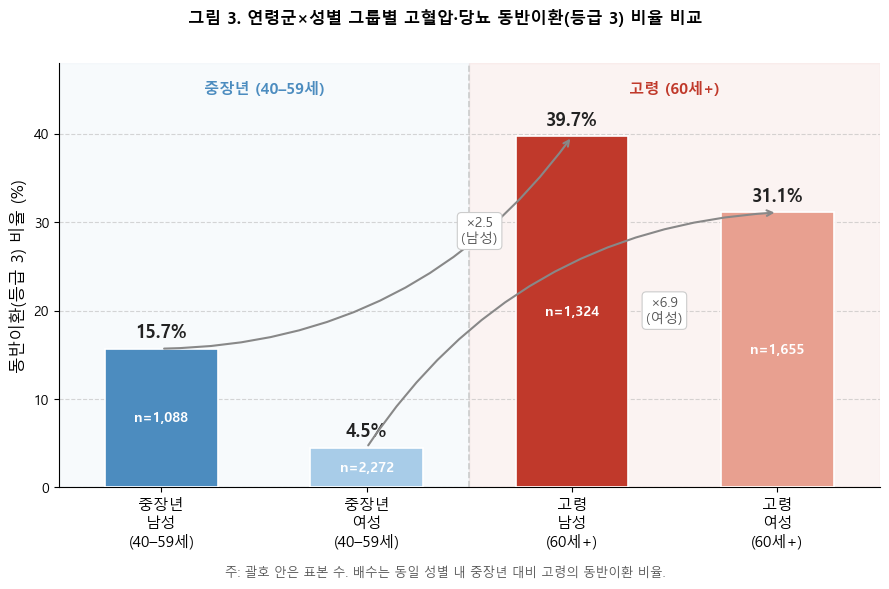

그림 4 저장 완료


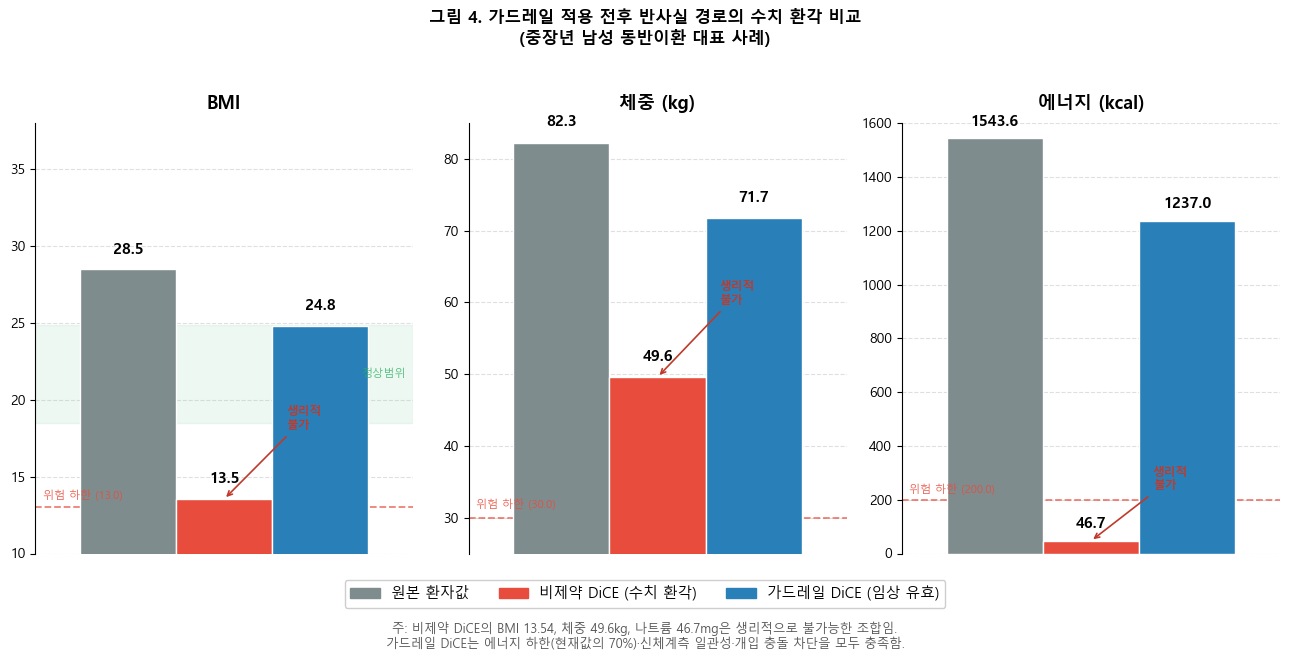

In [6]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# 한글 폰트 설정 (Windows: 맑은고딕, Mac/Linux: 나눔고딕)
import matplotlib
import platform

if platform.system() == 'Windows':
    matplotlib.rc('font', family='Malgun Gothic')
elif platform.system() == 'Darwin':
    matplotlib.rc('font', family='AppleGothic')
else:
    matplotlib.rc('font', family='NanumGothic')
matplotlib.rcParams['axes.unicode_minus'] = False

# ────────────────────────────────────────────────────────────────
# 그림 3: 연령×성별 그룹별 동반이환(등급 3) 비율 비교
# ────────────────────────────────────────────────────────────────

fig3, ax3 = plt.subplots(figsize=(9, 5.5))

groups     = ['중장년\n남성\n(40–59세)', '중장년\n여성\n(40–59세)',
              '고령\n남성\n(60세+)',     '고령\n여성\n(60세+)']
rates      = [15.7, 4.5, 39.7, 31.1]
sample_n   = [1088, 2272, 1324, 1655]
colors     = ['#4C8CBF', '#A8CCE8', '#C0392B', '#E8A090']

bars = ax3.bar(groups, rates, color=colors, width=0.55,
               edgecolor='white', linewidth=1.2, zorder=3)

# 막대 위 수치 + 표본 수 표기
for bar, rate, n in zip(bars, rates, sample_n):
    ax3.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.8,
             f'{rate}%', ha='center', va='bottom',
             fontsize=13, fontweight='bold',
             color='#222222')
    ax3.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() / 2,
             f'n={n:,}', ha='center', va='center',
             fontsize=10, color='white', fontweight='bold')

# 중장년 vs 고령 배경 구분
ax3.axvspan(-0.5, 1.5, alpha=0.04, color='#4C8CBF', zorder=0)
ax3.axvspan(1.5,  3.5, alpha=0.06, color='#C0392B', zorder=0)

# 배수 강조 화살표 + 텍스트
ax3.annotate('', xy=(2, 39.7), xytext=(0, 15.7),
             arrowprops=dict(arrowstyle='->', color='#888888',
                             lw=1.5, connectionstyle='arc3,rad=0.25'))
ax3.text(1.55, 29, '×2.5\n(남성)', ha='center', va='center',
         fontsize=10, color='#555555',
         bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='#cccccc', lw=0.8))

ax3.annotate('', xy=(3, 31.1), xytext=(1, 4.5),
             arrowprops=dict(arrowstyle='->', color='#888888',
                             lw=1.5, connectionstyle='arc3,rad=-0.25'))
ax3.text(2.45, 20, '×6.9\n(여성)', ha='center', va='center',
         fontsize=10, color='#555555',
         bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='#cccccc', lw=0.8))

# 상단 구분 레이블
ax3.text(0.5,  44.5, '중장년 (40–59세)', ha='center', fontsize=11,
         color='#4C8CBF', fontweight='bold')
ax3.text(2.5,  44.5, '고령 (60세+)',     ha='center', fontsize=11,
         color='#C0392B', fontweight='bold')
ax3.axvline(1.5, color='#cccccc', lw=1.2, linestyle='--', zorder=2)

ax3.set_ylabel('동반이환(등급 3) 비율 (%)', fontsize=12)
ax3.set_ylim(0, 48)
ax3.set_xlim(-0.5, 3.5)
ax3.yaxis.grid(True, linestyle='--', alpha=0.5, zorder=0)
ax3.set_axisbelow(True)
ax3.spines[['top', 'right']].set_visible(False)
ax3.tick_params(axis='x', labelsize=11)
ax3.tick_params(axis='y', labelsize=10)

fig3.suptitle('그림 3. 연령군×성별 그룹별 고혈압·당뇨 동반이환(등급 3) 비율 비교',
              fontsize=12, fontweight='bold', y=1.01)
fig3.text(0.5, -0.02,
          '주: 괄호 안은 표본 수. 배수는 동일 성별 내 중장년 대비 고령의 동반이환 비율.',
          ha='center', fontsize=9, color='#555555')

fig3.tight_layout()
fig3.savefig('그림3_동반이환비율비교.png', dpi=300, bbox_inches='tight',
             facecolor='white')
fig3.savefig('그림3_동반이환비율비교.pdf', bbox_inches='tight',
             facecolor='white')
print("그림 3 저장 완료")
plt.show()


# ────────────────────────────────────────────────────────────────
# 그림 4: 가드레일 적용 전후 수치 환각 비교 (중장년 여성 대표 사례)
# ────────────────────────────────────────────────────────────────

fig4, axes = plt.subplots(1, 3, figsize=(13, 5.5))

# --- 공통 설정 ---
metrics = ['BMI', '체중 (kg)', '에너지 (kcal)']
orig    = [28.48,  82.30,  1543.6]   # 원본 환자값 (중장년 남성)
no_grd  = [13.54,  49.60,    46.7]  # 비제약 DiCE 최악 사례 — BMI 불일치 + 나트륨 46mg
grd     = [24.82,  71.74,  1237.0]  # 가드레일 적용 DiCE (CF3)

# 각 서브플롯별 y축 범위
ylims   = [(10, 38), (25, 85), (0, 1600)]
# 생리적 정상 범위 (참고선)
normal_ranges = [(18.5, 24.9), (None, None), (500, None)]
# 생리적 하한 위험선
danger_lines  = [13.0, 30.0, 200.0]

bar_w = 0.28
x     = np.array([0])

for i, ax in enumerate(axes):
    # 막대 3개: 원본 / 비제약 / 가드레일
    b0 = ax.bar(x - bar_w, orig[i],   bar_w, label='원본 환자값',
                color='#7F8C8D', edgecolor='white', zorder=3)
    b1 = ax.bar(x,          no_grd[i], bar_w, label='비제약 DiCE',
                color='#E74C3C', edgecolor='white', zorder=3)
    b2 = ax.bar(x + bar_w,  grd[i],    bar_w, label='가드레일 DiCE',
                color='#2980B9', edgecolor='white', zorder=3)

    # 막대 위 수치
    for bar, val in zip([b0, b1, b2], [orig[i], no_grd[i], grd[i]]):
        ax.text(bar[0].get_x() + bar[0].get_width() / 2,
                bar[0].get_height() + ylims[i][1] * 0.02,
                f'{val:.1f}', ha='center', va='bottom',
                fontsize=11, fontweight='bold')

    # 생리적 정상 범위 음영
    lo, hi = normal_ranges[i]
    if lo is not None and hi is not None:
        ax.axhspan(lo, hi, alpha=0.08, color='#27AE60', zorder=0)
        ax.text(0.98, (lo + hi) / 2, '정상범위',
                transform=ax.get_yaxis_transform(),
                ha='right', va='center', fontsize=8,
                color='#27AE60', alpha=0.8)

    # 위험 하한선
    ax.axhline(danger_lines[i], color='#E74C3C', lw=1.3,
               linestyle='--', alpha=0.7, zorder=2)
    ax.text(0.02, danger_lines[i] + ylims[i][1] * 0.015,
            f'위험 하한 ({danger_lines[i]})',
            transform=ax.get_yaxis_transform(),
            fontsize=8, color='#E74C3C', alpha=0.9)

    # 비제약 수치에 위반 표시
    ax.annotate('생리적\n불가', xy=(0, no_grd[i]),
                xytext=(0.18, no_grd[i] + ylims[i][1] * 0.12),
                fontsize=8.5, color='#C0392B', fontweight='bold',
                arrowprops=dict(arrowstyle='->', color='#C0392B', lw=1.2))

    ax.set_title(metrics[i], fontsize=13, fontweight='bold', pad=10)
    ax.set_ylim(ylims[i])
    ax.set_xlim(-0.55, 0.55)
    ax.set_xticks([])
    ax.yaxis.grid(True, linestyle='--', alpha=0.4, zorder=0)
    ax.set_axisbelow(True)
    ax.spines[['top', 'right', 'bottom']].set_visible(False)

# 공통 범례
handles = [
    mpatches.Patch(color='#7F8C8D', label='원본 환자값'),
    mpatches.Patch(color='#E74C3C', label='비제약 DiCE (수치 환각)'),
    mpatches.Patch(color='#2980B9', label='가드레일 DiCE (임상 유효)'),
]
fig4.legend(handles=handles, loc='lower center', ncol=3,
            fontsize=10.5, frameon=True, framealpha=0.95,
            bbox_to_anchor=(0.5, -0.07))

fig4.suptitle('그림 4. 가드레일 적용 전후 반사실 경로의 수치 환각 비교\n'
              '(중장년 남성 동반이환 대표 사례)',
              fontsize=12, fontweight='bold', y=1.03)
fig4.text(0.5, -0.13,
          '주: 비제약 DiCE의 BMI 13.54, 체중 49.6kg, 나트륨 46.7mg은 생리적으로 불가능한 조합임.\n'
          '가드레일 DiCE는 에너지 하한(현재값의 70%)·신체계측 일관성·개입 충돌 차단을 모두 충족함.',
          ha='center', fontsize=9, color='#555555')

fig4.tight_layout()
fig4.savefig('그림4_가드레일전후비교.png', dpi=300, bbox_inches='tight',
             facecolor='white')
fig4.savefig('그림4_가드레일전후비교.pdf', bbox_inches='tight',
             facecolor='white')
print("그림 4 저장 완료")
plt.show()